# 01 — 금융모형 (GARCH(1,1) · HAR-RV)

구간(평시·9·11·GFC·COVID) × 국가(US·KR·JP) × 프로토콜(static·expanding) × phase 전체 그리드 평가.

**산출물**:
- `results/financial_results.csv` — 평가 그리드 (총 144행, 모델 2 × 그리드 72)
- `results/har_params.csv` — HAR-RV 정적 적합 계수
- `results/garch_params.csv` — GARCH(1,1) 정적 적합 계수 + 파생 지표

**모듈 구조**:
- `src/data_loader.py` — CSV 로드 + 날짜 분할
- `src/models/{garch,har_rv}.py` — 모델 wrapper
- `src/eval/{metrics,phases,protocols}.py` — 평가 4종 지표 + phase 슬라이서 + static/expanding 프로토콜

## 0. 환경 설정

In [7]:
# Colab인 경우 Drive 마운트 + 경로 설정 (로컬에선 무시됨)
import os, sys
from pathlib import Path

try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive', force_remount=False)
    # 사용자 환경에 맞게 수정
    os.environ['FINTEL_PROJECT_ROOT'] = '/content/drive/MyDrive/대학교/학부4학년_추가/datasciencecapstone/Project'
except ImportError:
    pass

# src 모듈 import 가능하도록 Project 루트를 sys.path에 추가
PROJECT_ROOT = Path(os.environ.get('FINTEL_PROJECT_ROOT', Path.cwd().parent))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('PROJECT_ROOT =', PROJECT_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_ROOT = /content/drive/MyDrive/대학교/학부4학년_추가/datasciencecapstone/Project


In [8]:
!pip install -q -r /content/drive/MyDrive/대학교/학부4학년_추가/datasciencecapstone/Project/requirements.txt

In [9]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

from src import config
from src.data_loader import load_split
from src.models import GARCHModel, HARRVModel
from src.eval import evaluate, iter_phases, run_static, run_expanding

## 1. 그리드 정의

In [10]:
MODEL_REGISTRY = {
    'GARCH': GARCHModel,
    'HAR_RV': HARRVModel,
}

# expanding refit 빈도 — 개발 중엔 5~10으로 키워 빠르게 검증, 최종 실행은 1
REFIT_EVERY = 1

print('regimes  :', config.REGIMES)
print('countries:', config.COUNTRIES)
print('models   :', list(MODEL_REGISTRY))
print('protocols:', config.PROTOCOLS)
print('metrics  :', config.METRICS)

regimes  : ['normal', '911', 'gfc', 'covid']
countries: ['US', 'KR', 'JP']
models   : ['GARCH', 'HAR_RV']
protocols: ['static', 'expanding']
metrics  : ['RMSE', 'MAE', 'QLIKE', 'RMSE_CV']


## 2. 그리드 실행

In [11]:
results = []
preds_cache = {}  # (model, regime, country, protocol) -> pd.Series (시각화용)

t_total = time.time()
for regime in config.REGIMES:
    for country in config.COUNTRIES:
        train, test = load_split(regime, country)
        print(f'\n[{regime} / {country}] train={len(train)}, test={len(test)}')

        for model_name, ModelCls in MODEL_REGISTRY.items():
            for protocol_name in config.PROTOCOLS:
                t0 = time.time()
                if protocol_name == 'static':
                    y_pred = run_static(ModelCls, train, test)
                else:
                    y_pred = run_expanding(ModelCls, train, test, refit_every=REFIT_EVERY)
                elapsed = time.time() - t0

                preds_cache[(model_name, regime, country, protocol_name)] = y_pred

                # phase별 평가
                for phase_name, mask, color in iter_phases(test, regime):
                    if mask.sum() == 0:
                        continue
                    y_true_phase = test.loc[mask, 'RV_target']
                    y_pred_phase = y_pred[mask]
                    metrics = evaluate(y_true_phase, y_pred_phase)
                    results.append({
                        'model': model_name,
                        'regime': regime,
                        'country': country,
                        'protocol': protocol_name,
                        'phase': phase_name,
                        **metrics,
                    })
                print(f'  {model_name:<8} {protocol_name:<10} ({elapsed:.1f}s)')

results_df = pd.DataFrame(results)
print(f'\n총 행: {len(results_df)} (예상 144), 총 소요: {time.time()-t_total:.1f}s')


[normal / US] train=3488, test=1502
  GARCH    static     (0.1s)
  GARCH    expanding  (63.3s)
  HAR_RV   static     (0.0s)
  HAR_RV   expanding  (14.3s)

[normal / KR] train=3426, test=1475
  GARCH    static     (0.0s)
  GARCH    expanding  (63.6s)
  HAR_RV   static     (0.0s)
  HAR_RV   expanding  (14.2s)

[normal / JP] train=3393, test=1460
  GARCH    static     (0.0s)
  GARCH    expanding  (51.4s)
  HAR_RV   static     (0.0s)
  HAR_RV   expanding  (14.1s)

[911 / US] train=396, test=135
  GARCH    static     (0.0s)
  GARCH    expanding  (2.8s)
  HAR_RV   static     (0.0s)
  HAR_RV   expanding  (1.0s)

[911 / KR] train=388, test=136
  GARCH    static     (0.0s)
  GARCH    expanding  (2.6s)
  HAR_RV   static     (0.0s)
  HAR_RV   expanding  (1.0s)

[911 / JP] train=392, test=133
  GARCH    static     (0.0s)
  GARCH    expanding  (4.0s)
  HAR_RV   static     (0.0s)
  HAR_RV   expanding  (1.0s)

[gfc / US] train=1867, test=483
  GARCH    static     (0.0s)
  GARCH    expanding  (16.1s)

## 3. 결과 저장

In [12]:
config.RESULTS_DIR.mkdir(parents=True, exist_ok=True)
out_path = config.RESULTS_DIR / 'financial_results.csv'
results_df.to_csv(out_path, index=False)
print('saved →', out_path)
results_df.head()

saved → /content/drive/MyDrive/대학교/학부4학년_추가/datasciencecapstone/Project/results/financial_results.csv


,model,regime,country,protocol,phase,RMSE,MAE,QLIKE,RMSE_CV
0,GARCH,normal,US,static,Full Test,0.386547,0.308570,0.137020,0.660674
1,GARCH,normal,US,expanding,Full Test,0.381029,0.302427,0.133128,0.651244
2,HAR_RV,normal,US,static,Full Test,0.257075,0.157380,0.054131,0.439385
3,HAR_RV,normal,US,expanding,Full Test,0.256396,0.156319,0.053619,0.438225
4,GARCH,normal,KR,static,Full Test,0.361991,0.325469,0.123113,0.680931


## 4. 모델 파라미터 추출 및 저장 (static 한정)

Static fit으로 (regime × country)당 1회씩 적합한 뒤 핵심 계수를 모음.
Expanding은 매 step마다 파라미터가 달라져 단일 표 표현이 부적합하므로 제외.

**산출**:
- `results/har_params.csv` — `regime, country, const, RV_d, RV_w, RV_m`
- `results/garch_params.csv` — `regime, country, omega, alpha, beta, persistence, half_life, long_run_variance`

**파생 지표 정의**:
- `persistence` = α + β
- `half_life` = log(0.5) / log(α + β)
- `long_run_variance` = ω / (1 − α − β)

In [13]:
# ── 모델 파라미터 추출 및 저장 (static 한정) ──
# (regime × country)당 1회 fit → 핵심 계수 + GARCH 파생 지표(persistence/half-life/long-run var)
# 결과: results/har_params.csv, results/garch_params.csv

har_rows = []
garch_rows = []

for regime in config.REGIMES:
    for country in config.COUNTRIES:
        train, _ = load_split(regime, country)

        # HAR-RV — 핵심 계수 4개
        har = HARRVModel().fit(train)
        p = har.params_
        har_rows.append({
            'regime': regime,
            'country': country,
            'const': float(p['const']),
            'RV_d': float(p['RV_d']),
            'RV_w': float(p['RV_w']),
            'RV_m': float(p['RV_m']),
        })

        # GARCH(1,1) — 핵심 계수 + 파생 지표
        g = GARCHModel().fit(train)
        persistence = g.alpha_ + g.beta_
        if persistence < 1:
            half_life = float(np.log(0.5) / np.log(persistence))
            long_run_var = float(g.omega_ / (1.0 - persistence))
        else:
            half_life = float('nan')
            long_run_var = float('nan')
        garch_rows.append({
            'regime': regime,
            'country': country,
            'omega': g.omega_,
            'alpha': g.alpha_,
            'beta': g.beta_,
            'persistence': persistence,
            'half_life': half_life,
            'long_run_variance': long_run_var,
        })

har_params_df = pd.DataFrame(har_rows)
garch_params_df = pd.DataFrame(garch_rows)

config.RESULTS_DIR.mkdir(parents=True, exist_ok=True)
har_params_df.to_csv(config.RESULTS_DIR / 'har_params.csv', index=False)
garch_params_df.to_csv(config.RESULTS_DIR / 'garch_params.csv', index=False)
print('saved → har_params.csv, garch_params.csv')

display(har_params_df.round(4))
display(garch_params_df.round(4))

saved → har_params.csv, garch_params.csv


,regime,country,const,RV_d,RV_w,RV_m
0,normal,US,0.0504,0.3403,0.4225,0.1841
1,normal,KR,0.0597,0.3994,0.3939,0.1504
2,normal,JP,0.0754,0.4299,0.3236,0.1688
3,911,US,0.1918,0.3553,0.2371,0.2378
4,911,KR,0.1804,0.3847,0.3638,0.1407
5,911,JP,0.2880,0.2596,0.4243,0.0746
6,gfc,US,0.0517,0.2868,0.4326,0.2214
7,gfc,KR,0.0795,0.3150,0.4339,0.1835
8,gfc,JP,0.0736,0.3004,0.4167,0.2063
9,covid,US,0.0445,0.3779,0.3856,0.1834


,regime,country,omega,alpha,beta,persistence,half_life,long_run_variance
0,normal,US,0.0153,0.0868,0.9029,0.9897,67.0438,1.4846
1,normal,KR,0.0157,0.0783,0.9181,0.9964,192.9428,4.3722
2,normal,JP,0.0441,0.0861,0.8923,0.9783,31.6409,2.0336
3,911,US,0.0750,0.1170,0.8498,0.9668,20.5363,2.2592
4,911,KR,0.5293,0.1352,0.7876,0.9228,8.6250,6.8540
5,911,JP,0.0992,0.0546,0.8975,0.9521,14.1179,2.0699
6,gfc,US,0.0105,0.0664,0.9241,0.9905,72.6396,1.1088
7,gfc,KR,0.0210,0.0742,0.9219,0.9961,178.1024,5.3976
8,gfc,JP,0.0223,0.0676,0.9207,0.9883,59.1501,1.9100
9,covid,US,0.0200,0.1098,0.8742,0.9841,43.1716,1.2551


## 5. 시계열 예측 로그 저장 (log/{model}/log_{model}_{regime}_{country}.csv)

각 (model, regime, country) 조합당 1개 CSV. test 구간의 RV_target과 모델 예측을 long format으로 저장.

**컬럼**: `date, protocol, RV_target, RV_pred`
**행 수**: test 길이 × 2 protocol

In [14]:
from collections import defaultdict

# preds_cache: (model_name, regime, country, protocol) → pd.Series  (Section 2에서 누적)
# 모델 이름은 MODEL_REGISTRY 키 ('GARCH', 'HAR_RV')

LOG_DIR = PROJECT_ROOT / 'log'
LOG_DIR.mkdir(parents=True, exist_ok=True)
for model_name in MODEL_REGISTRY:
    (LOG_DIR / model_name).mkdir(parents=True, exist_ok=True)

# (model, regime, country) 단위로 그룹핑 → 한 CSV에 두 protocol 모두 long format으로
groups = defaultdict(list)
for (model_name, regime, country, protocol), y_pred in preds_cache.items():
    groups[(model_name, regime, country)].append((protocol, y_pred))

saved_files = []
for (model_name, regime, country), protocol_series in groups.items():
    _, test = load_split(regime, country)
    test_idx = test.index

    rows = []
    for protocol, y_pred in protocol_series:
        rows.append(pd.DataFrame({
            'date': test_idx,
            'protocol': protocol,
            'RV_target': test['RV_target'].values,
            'RV_pred': y_pred.reindex(test_idx).values,
        }))
    out_df = pd.concat(rows, ignore_index=True)

    out_path = LOG_DIR / model_name / f'log_{model_name}_{regime}_{country}.csv'
    out_df.to_csv(out_path, index=False)
    saved_files.append(out_path)

print(f'saved → {len(saved_files)}개 CSV')
print(f'예시: {saved_files[0].relative_to(PROJECT_ROOT)}')
print(f'      {saved_files[1].relative_to(PROJECT_ROOT)}')
print(f'      ...')
print(f'예상: 모델 2 (GARCH, HAR_RV) × 12 (regime × country) = 24 파일')

saved → 24개 CSV
예시: log/GARCH/log_GARCH_normal_US.csv
      log/HAR_RV/log_HAR_RV_normal_US.csv
      ...
예상: 모델 2 (GARCH, HAR_RV) × 12 (regime × country) = 24 파일


## 6. 빠른 비교 — 모델 × 구간 (Full Test 기준 QLIKE)

In [15]:
summary = (
    results_df[results_df['phase'] == 'Full Test']
    .groupby(['model', 'regime', 'protocol'])['QLIKE']
    .mean()
    .unstack('regime')
    .round(4)
)
summary

regime               911   covid     gfc  normal
model  protocol                                 
GARCH  expanding  0.0899  0.1563  0.0804  0.1490
       static     0.0856  0.1577  0.0802  0.1562
HAR_RV expanding  0.0342  0.0547  0.0346  0.0454
       static     0.0340  0.0549  0.0348  0.0458

## 7. 시각화 — 위기 phase 영역 음영

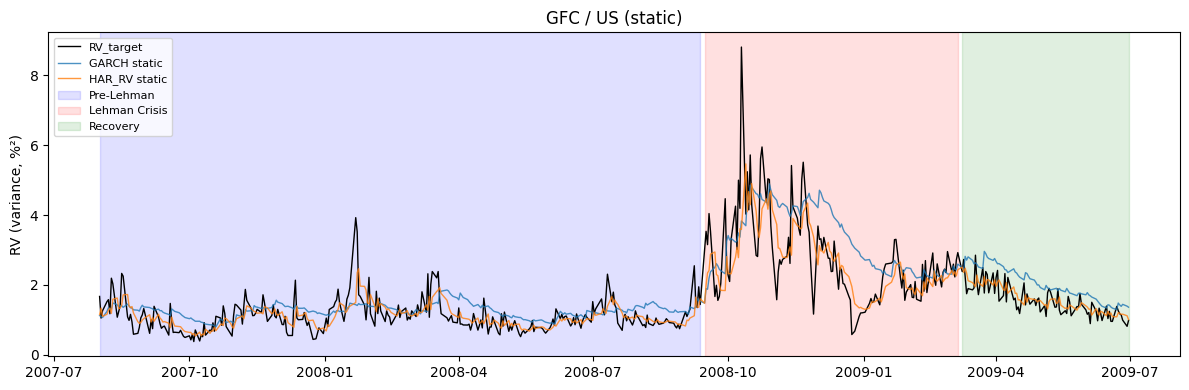

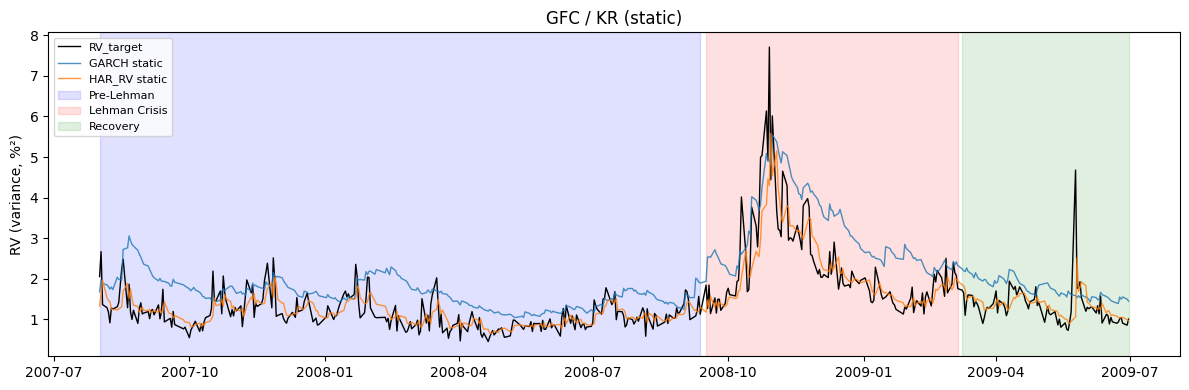

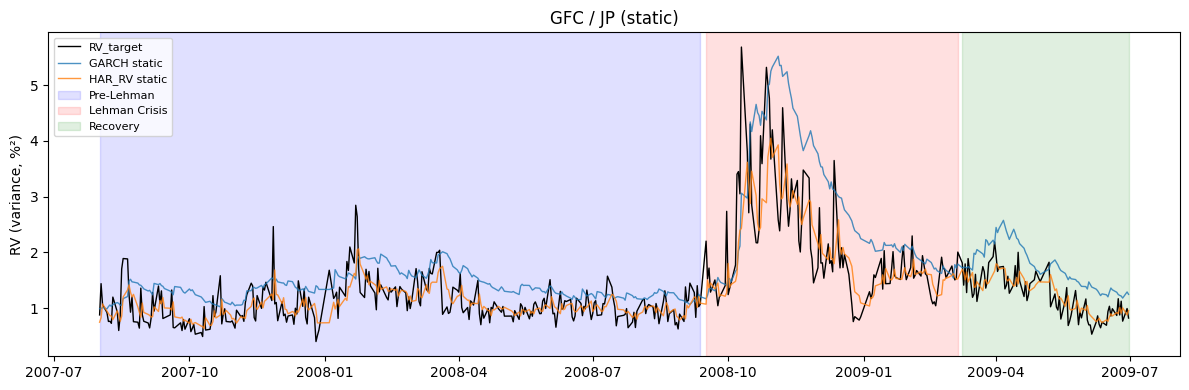

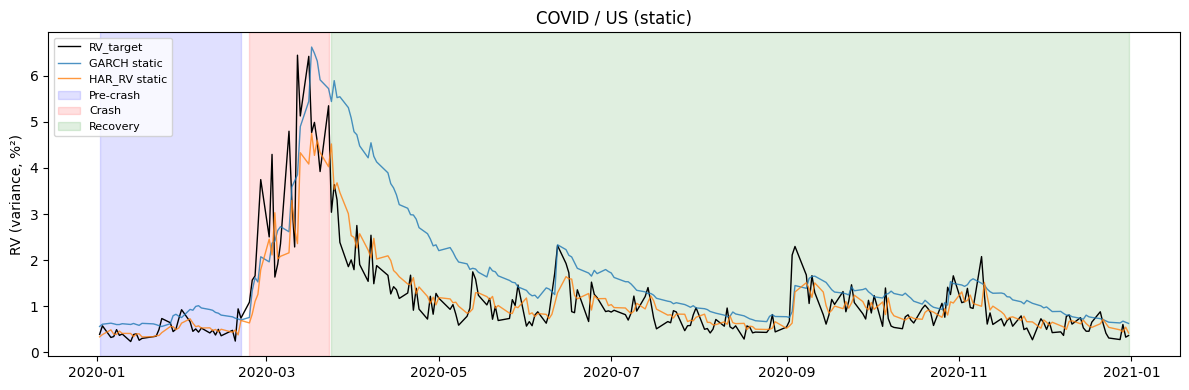

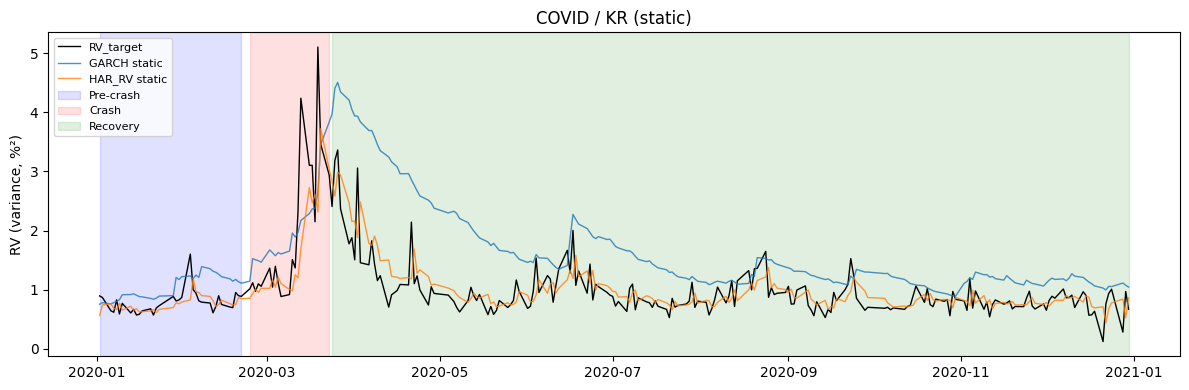

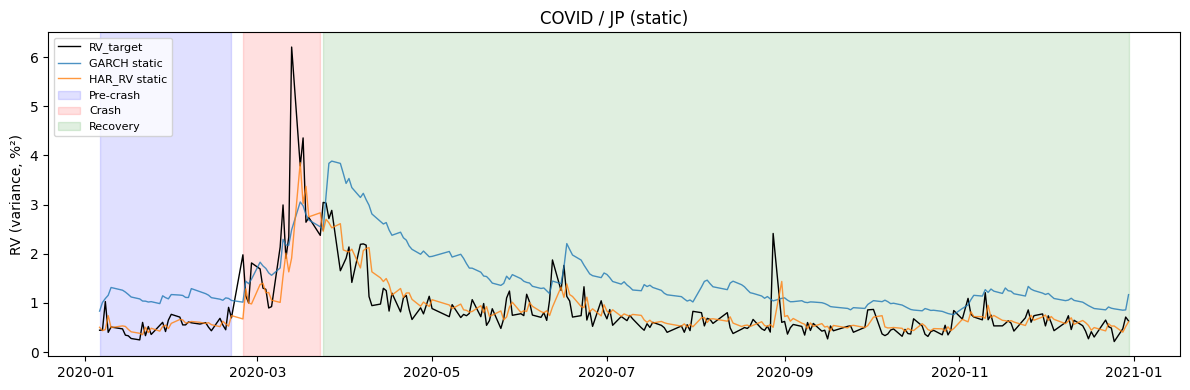

In [16]:
def plot_predictions(regime: str, country: str, protocol: str = 'static'):
    train, test = load_split(regime, country)
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(test.index, test['RV_target'], color='black', lw=1, label='RV_target')
    for model_name in MODEL_REGISTRY:
        key = (model_name, regime, country, protocol)
        if key in preds_cache:
            ax.plot(test.index, preds_cache[key], lw=1, alpha=0.8, label=f'{model_name} {protocol}')
    # phase 영역 음영 (color가 명시된 phase만)
    for name, mask, color in iter_phases(test, regime):
        if name == 'Full Test' or color is None:
            continue
        idx = test.index[mask]
        if len(idx) > 0:
            ax.axvspan(idx.min(), idx.max(), color=color, alpha=0.12, label=name)
    ax.set_title(f'{regime.upper()} / {country} ({protocol})')
    ax.set_ylabel('RV (variance, %²)')
    ax.legend(loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()

for regime in ['gfc', 'covid']:
    for country in config.COUNTRIES:
        plot_predictions(regime, country, 'static')